- Modification for 'Turbustat' versions for sysnthetic:
    - two-dimensional (https://turbustat.readthedocs.io/en/latest/api/turbustat.simulator.make_extended.html#turbustat.simulator.make_extended)
    - and three-dimensional fields (https://turbustat.readthedocs.io/en/latest/api/turbustat.simulator.make_3dfield.html#make-3dfield)


In [1]:
import time
start_time=time.time()

In [141]:
import numpy as np
import seaborn as sns
import pandas as pd
import sys
from spectral_cube import SpectralCube
from turbustat.simulator import make_ppv
from pathlib import Path
import astropy.units as u
from matplotlib import pyplot as plt
from skimage.util import random_noise
import corner
import json
from astropy.io import fits


# Add path to py_modules 

sys.path.append(str(Path().resolve() / 'py_modules')) # 1 level up = project root

from turb_utils import make_extended, make_3dfield
import strucfunc
import bfunc
import bplot

In [111]:
import ci_results_compiler
import fit_structure_function
import importlib

In [51]:
# Physical parameters

N     = 512
ra    = N / 16 # Artificial correlation length
m_obs = 1.0    # The projected slope of the structure function we measure in nature
m2D   = 0.85   # for recovering m as 1.00 in the projected field (k = 2D + m2D) non emissivity fluctuation case
m3D_1 = 0.30   # for recovering m as 1.00 in the projected field (k = 3D + m3D) light fluctuations
m3D_2 = 0.55   # for recovering m as 1.00 in the projected field (k = 3D + m3D) heavy fluctuations

From: https://github.com/JavGVastro/PhD.Paper/issues/18

As suggestion from somewhere, the power spectra is in terms of numbers of dimensions (ND) and the N-dimensional slope structure function.

$$\kappa = \text{ND} + m_\text{ND}$$

# Modification

$$e^{-\dfrac{1}{2 \pi k r_0}}$$


``` python
    if ellip < 1:
        # Apply a rotation and scale the x-axis (ellip).
        costheta = np.cos(theta)
        sintheta = np.sin(theta)

        xprime = ellip * (xx * costheta - yy * sintheta)
        yprime = xx * sintheta + yy * costheta

        rr2 = xprime ** 2 + yprime ** 2

        rr = rr2 ** 0.5
        # Also save circular version to use with correlation_length <-----------
        rcirc = np.hypot(xx, yy)   <-----------
        rcirc[rcirc == 0.0] = np.nan  <-----------
    else:
        # Circular whenever ellip == 1
        rr = (xx ** 2 + yy ** 2) ** 0.5

    # flag out the bad point to avoid warnings
    rr[rr == 0] = np.nan

    if correlation_length is not None:     <-----------
        # Taper the power spectrum at large separations (low spatial   <-----------
        # frequencies) so that the field is uncorrelated at the <-----------
        # largest scales. <-----------
        #
        # rcirc is spatial frequency: 1 / r, measured in pixels <-----------
        output *= np.exp(-1.0 / (2 * np.pi * rcirc * correlation_length)) <-----------
```




# Fake velocity fields

In [4]:
# Tapered map
vmap = make_extended(
    N,
    powerlaw           = 2.0 + m2D,
    ellip              = 0.5,
    theta              = 45,
    correlation_length = ra,
    randomseed         = 1894_04_25,
)
signorm = vmap.std()
vmap /= signorm


# Non tapered map
vmap0 = make_extended(
    N,
    powerlaw      = 2.0 + m2D,
    ellip         = 0.5,
    theta         = 45,
    randomseed    = 1894_04_25,
)
signorm0 = vmap0.std()
vmap0 /= signorm0

signorm, signorm0

(1.8482080520449609, 4.349222322625375)

<>:11: SyntaxWarning: invalid escape sequence '\s'
<>:11: SyntaxWarning: invalid escape sequence '\s'
C:\Users\ZAINTEL2\AppData\Local\Temp\ipykernel_19844\1582354251.py:11: SyntaxWarning: invalid escape sequence '\s'
  cbar.set_label("$\sigma$ (-)", rotation=270, labelpad=15)


Text(0.5, 1.0, '2D Non Tapered')

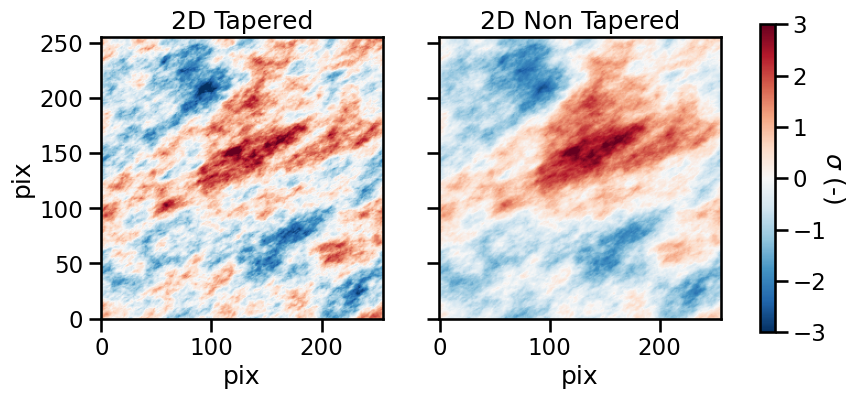

In [66]:
fig, (ax, axx) = plt.subplots(
    1,
    2,
    sharey=True,
    figsize=(10, 4),
)
imshow_kwds = dict(origin="lower", vmin=-3, vmax=3, cmap="RdBu_r")
im = ax.imshow(vmap, **imshow_kwds)
im = axx.imshow(vmap0, **imshow_kwds)
cbar = fig.colorbar(im, ax=[ax, axx])
cbar.set_label("$\sigma$ (-)", rotation=270, labelpad=15)

ax.set_xlabel("pix")
ax.set_ylabel("pix")
axx.set_xlabel("pix")

ax.set_title("2D Tapered")
axx.set_title("2D Non Tapered")

In [142]:
name  = 'fake_map_mod_finite_m2.85_r32_N512'
name0 = 'fake_map_finite_m2.85_r32_N512'


In [143]:
hdu = fits.PrimaryHDU(data=vmap)
hdul = fits.HDUList([hdu])
hdul.writeto(name + '.fits')

In [144]:
hdu0 = fits.PrimaryHDU(data=vmap0)
hdul0 = fits.HDUList([hdu0])
hdul0.writeto(name0 + '.fits')

# Structure function

In [6]:
sf = strucfunc.strucfunc_numba_parallel(vmap, dlogr=0.05)
sf0 = strucfunc.strucfunc_numba_parallel(vmap0, dlogr=0.05)

C:\Users\ZAINTEL2\Dropbox\GitHub\fake_maps\py_modules\strucfunc.py:83: RuntimeWarning: invalid value encountered in divide
  'Unweighted B(r)': sf/nsf,
C:\Users\ZAINTEL2\Dropbox\GitHub\fake_maps\py_modules\strucfunc.py:84: RuntimeWarning: invalid value encountered in divide
  'Weighted B(r)': wsf/weight}


In [115]:
mask = sf["N pairs"] > 0
r = 10 ** sf["log10 r"][mask]
B = sf["Unweighted B(r)"][mask]
B0 = sf0["Unweighted B(r)"][mask]

In [127]:
# Export results from Numba structure function
data_export = {
    'strucfun_numba_parallel' : sf,
}

In [132]:
class MyEncoder(json.JSONEncoder):
    def default(self, obj):
        if isinstance(obj, np.integer):
            return int(obj)
        elif isinstance(obj, np.floating):
            return float(obj)
        elif isinstance(obj, np.ndarray):
            return obj.tolist()
        else:
            return super(MyEncoder, self).default(obj)

In [139]:
# Export results from Numba structure function
data_export = {
    'strucfun_numba_parallel' : sf,
}

jsonfilename = name +".json"
with open(jsonfilename, "w") as f:
    json.dump(data_export, fp=f, indent=3, cls=MyEncoder)

In [138]:
# Export results from Numba structure function
data_export = {
    'strucfun_numba_parallel' : sf0,
}

jsonfilename = name0 +".json"
with open(jsonfilename, "w") as f:
    json.dump(data_export, fp=f, indent=3, cls=MyEncoder)

## Plot B(r)

In [116]:
scale * rgrid ** (m2D)

array([ 0.08      ,  0.08840103,  0.09768428,  0.10794239,  0.11927773,
        0.13180343,  0.14564449,  0.16093904,  0.17783972,  0.19651518,
        0.21715181,  0.23995555,  0.26515398,  0.29299857,  0.3237672 ,
        0.35776693,  0.39533707,  0.43685256,  0.48272771,  0.53342035,
        0.58943636,  0.65133479,  0.71973334,  0.79531462,  0.87883291,
        0.9711217 ,  1.07310201,  1.18579156,  1.31031497,  1.44791494,
        1.59996468,  1.76798161,  1.95364248,  2.15880013,  2.38550199,
        2.63601046,  2.91282556,  3.21870981,  3.55671585,  3.93021689,
        4.34294035,  4.7990051 ,  5.30296253,  5.85984199,  6.47520097,
        7.15518059,  7.90656683,  8.73685832,  9.65434113, 10.66817146])

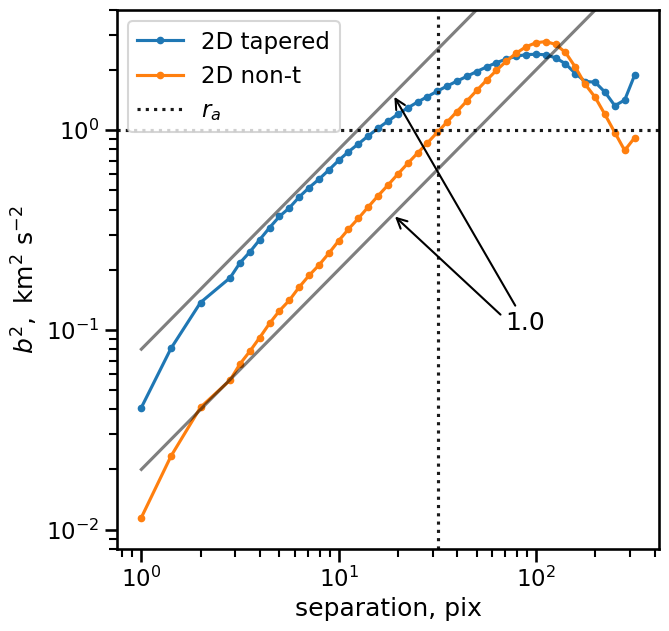

In [117]:
fig, ax = plt.subplots(figsize=(7, 7))

ax.plot(r, B, marker=".", label = '2D tapered')
ax.plot(r, B0, marker=".", label = '2D non-t')

ax.axhline(1.0, color="k", linestyle="dotted")
ax.axvline(ra, color="k", linestyle="dotted", label = r'$r_a$')
#ax.axvline(N / 2, color="k", linestyle="dashed")
#ax.axvline(N / 6, color="k", linestyle="dashed")

rgrid = np.logspace(0.0, 2.5)

for scale in 0.02, 0.08:
    ax.plot(rgrid, scale * rgrid ** (m_obs), color="black", alpha = 0.5)
    

ax.set(
    xlabel='separation, pix',
    ylabel=r'$b^2,\ \mathrm{km^2\ s^{-2}}$',
    xscale="log",
    yscale="log",
    ylim=[8e-3, 4],
)

ax.annotate(
    str(m_obs),           # text
    xy=(rgrid[len(rgrid)//2], 0.08 * rgrid[len(rgrid)//2] ** (m_obs)),            
    xytext=(70, 0.1),          # location of the text (data coords)
    arrowprops=dict(arrowstyle="->")  # arrow style
)

ax.annotate(
    ' ',           # text
    xy=(rgrid[len(rgrid)//2], 0.02 * rgrid[len(rgrid)//2] ** (m_obs)),            
    xytext=(70, 0.1),          # location of the text (data coords)
    arrowprops=dict(arrowstyle="->")  # arrow style
)

ax.legend()


# Confidence Interval

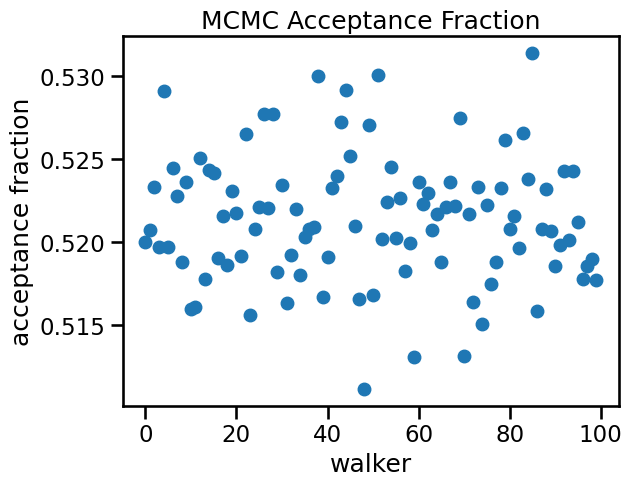

Autocorrelation time for the parameters:
----------------------------------------
r0 = 62.962
sig2 = 62.922
m = 62.976
s0 = 71.833
noise = 86.420


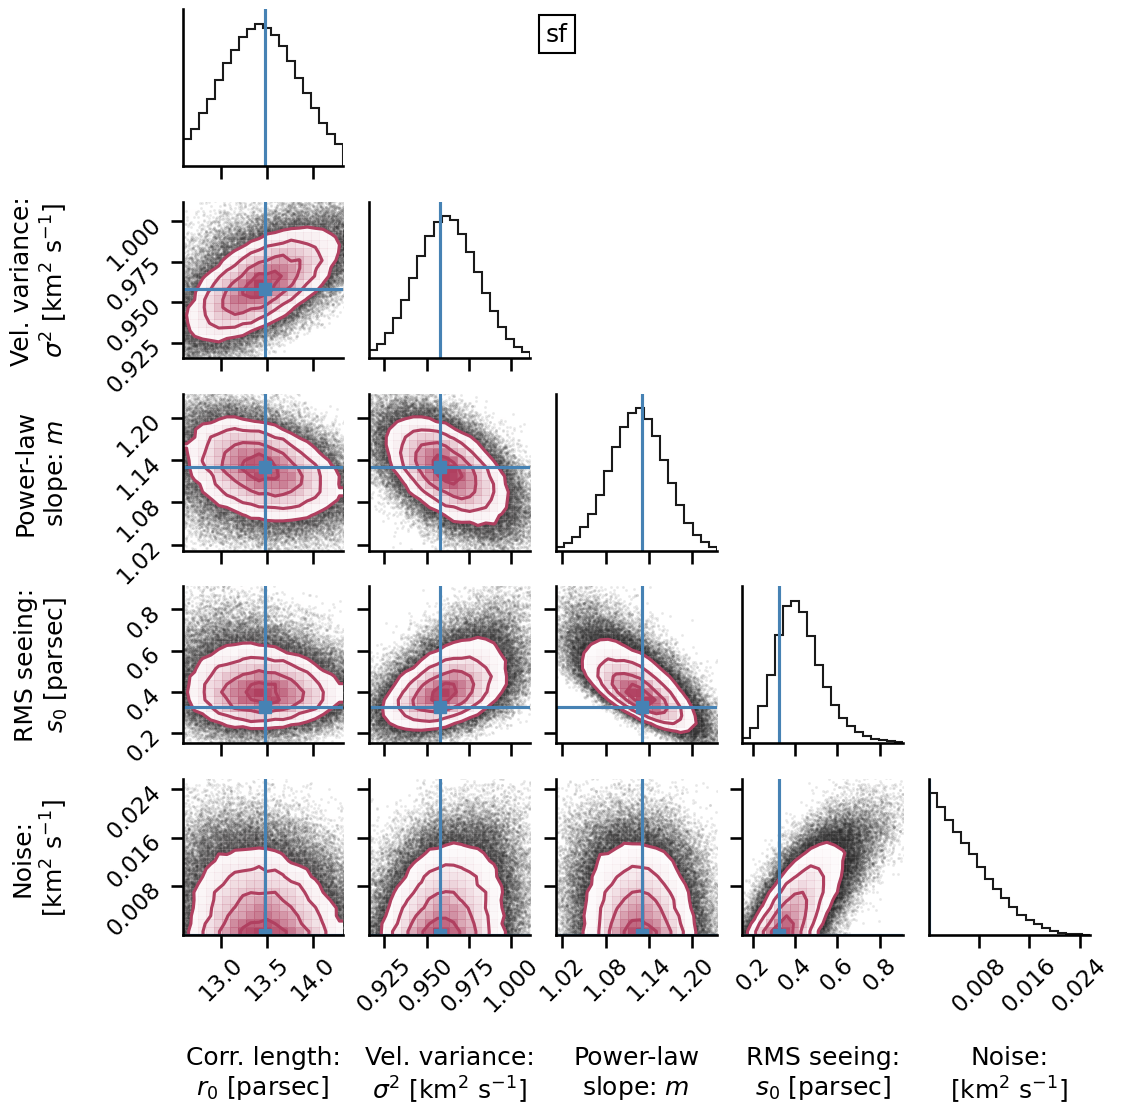

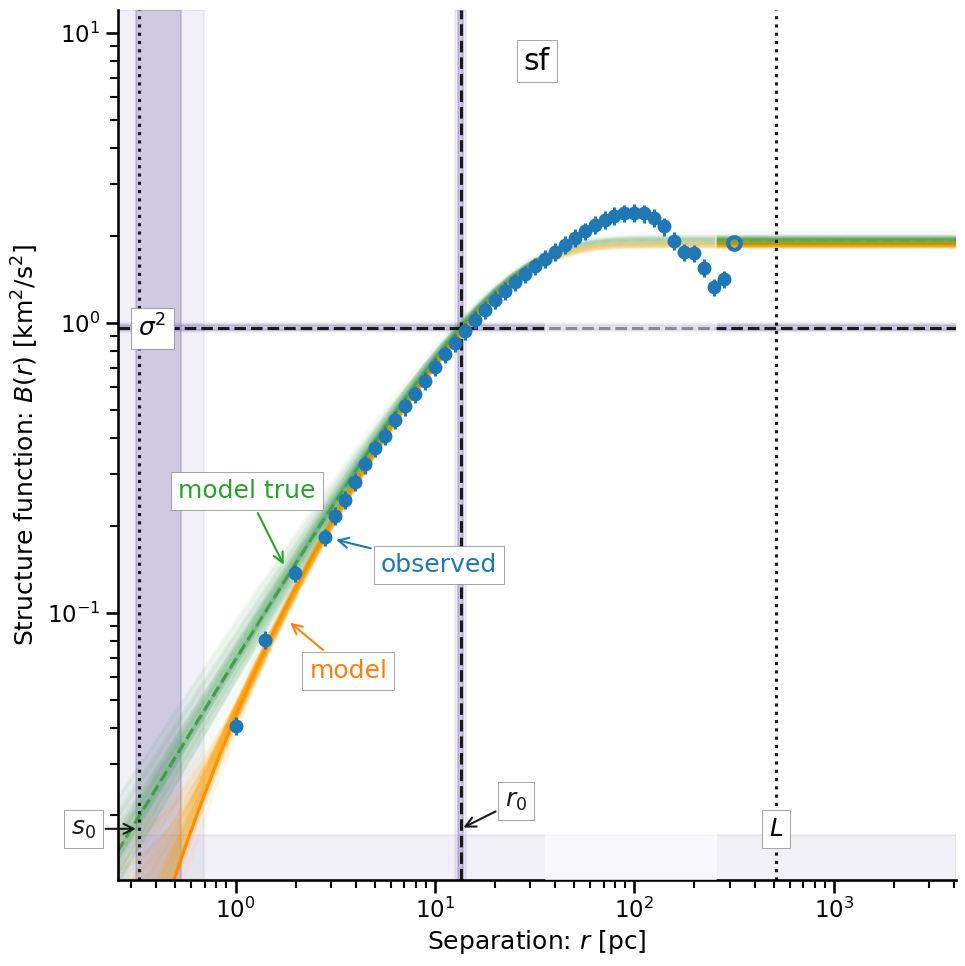

In [91]:
results = fit_structure_function.fit_structure_function(sf, N, bfunc=bfunc, bplot=bplot, name = 'sf', data = 'sf')

C:\Users\ZAINTEL2\anaconda3\Lib\site-packages\emcee\moves\red_blue.py:99: RuntimeWarning: invalid value encountered in scalar subtract
  lnpdiff = f + nlp - state.log_prob[j]


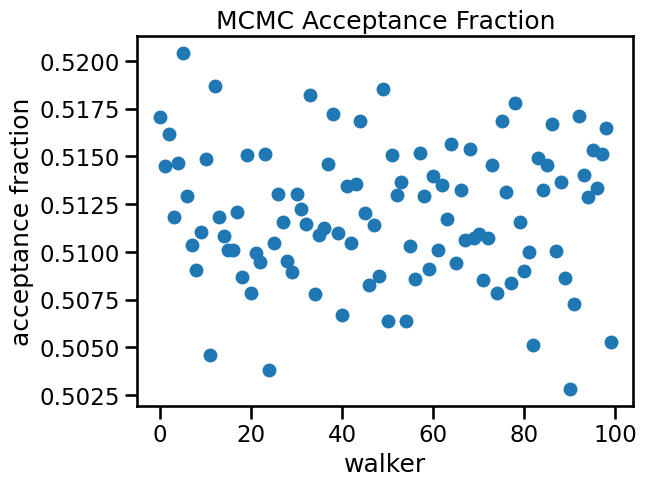

Autocorrelation time for the parameters:
----------------------------------------
r0 = 65.067
sig2 = 66.081
m = 66.529
s0 = 74.192
noise = 75.053


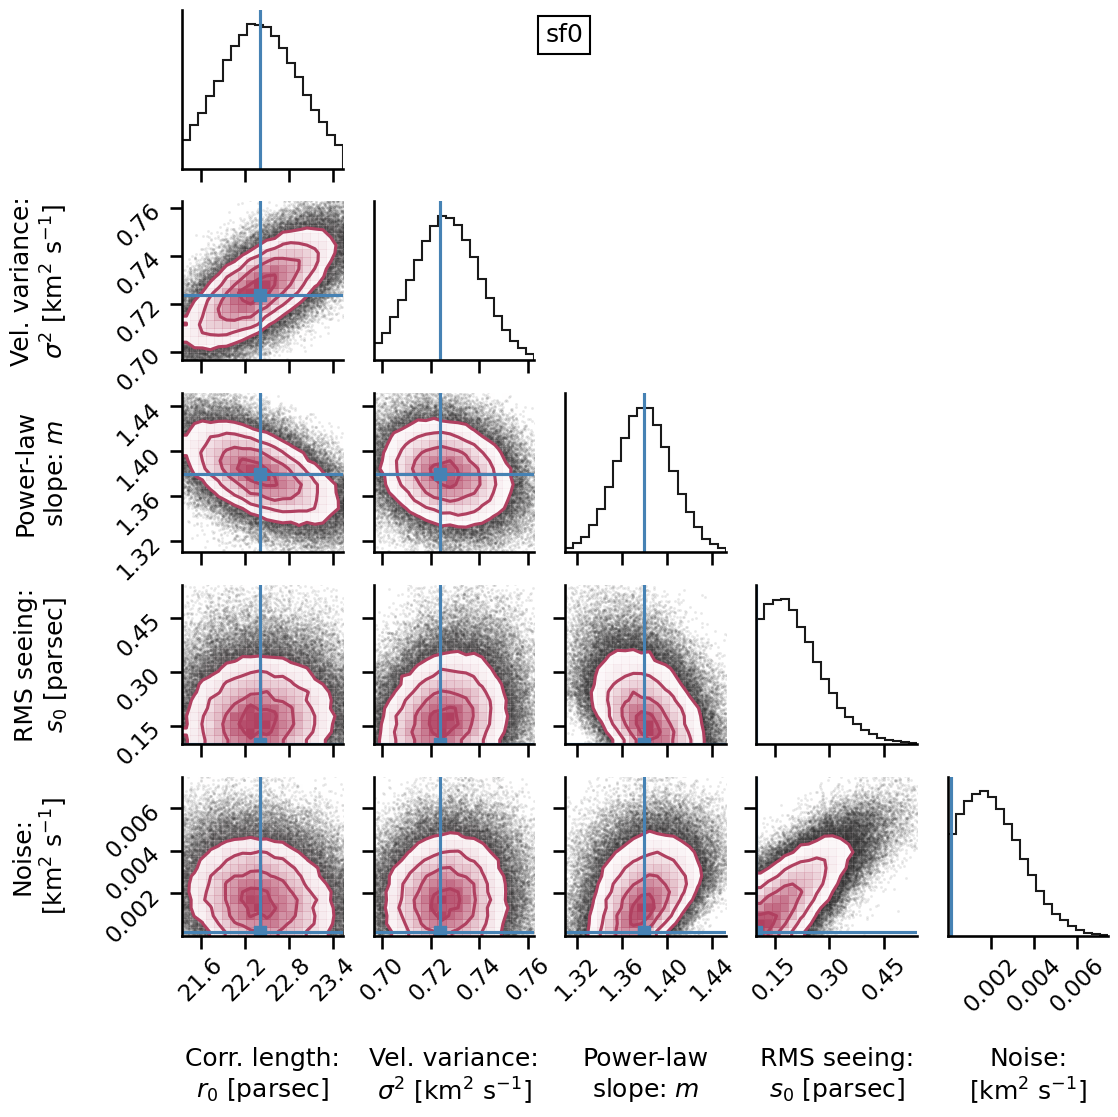

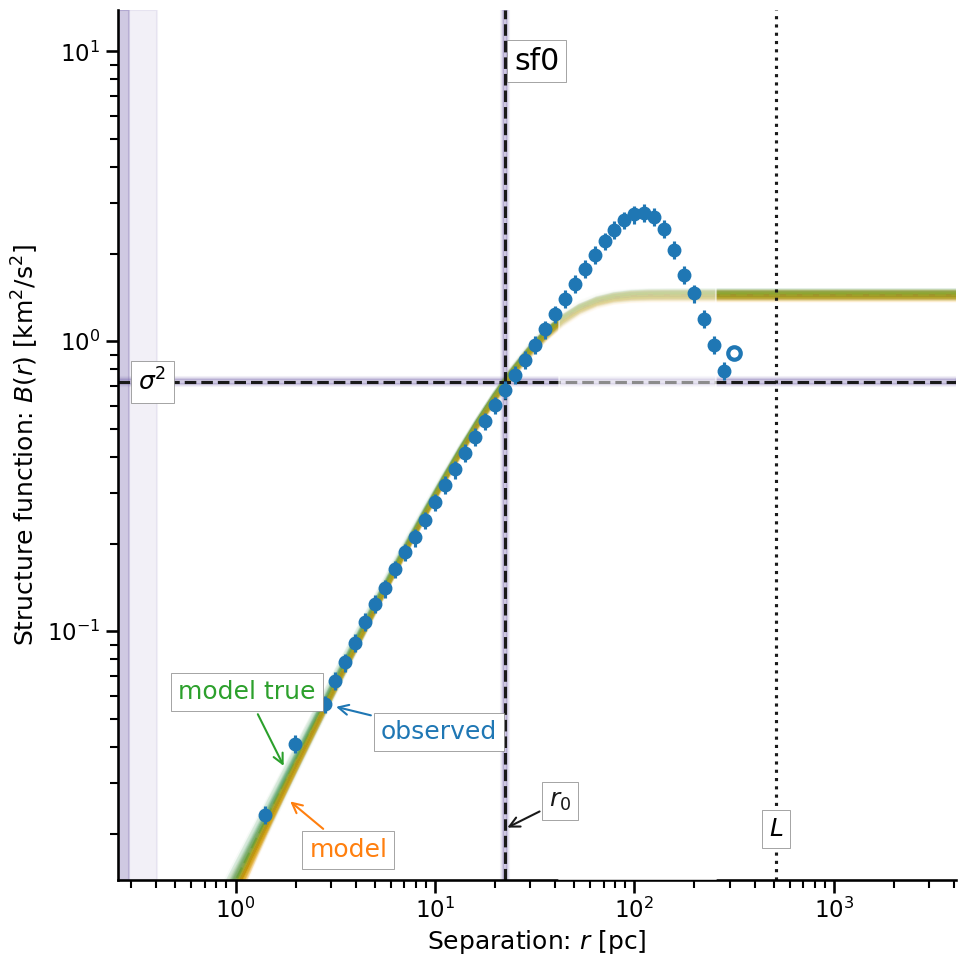

In [72]:
results0 = fit_structure_function.fit_structure_function(sf0, N, bfunc=bfunc, bplot=bplot, name = 'sf0', data = 'sf0')

In [73]:
res = ci_results_compiler.ci_results_compiler(results)

In [74]:
res0 = ci_results_compiler.ci_results_compiler(results0)

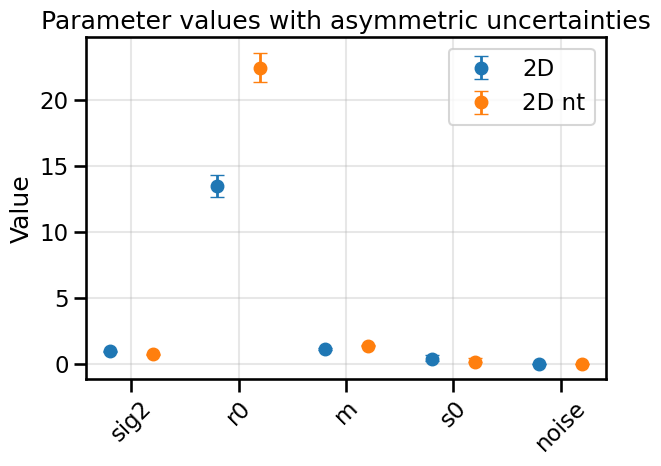

In [76]:
ci_results_compiler.plot_param_comp(res,res0, labels=['2D','2D nt'], decimals=4)


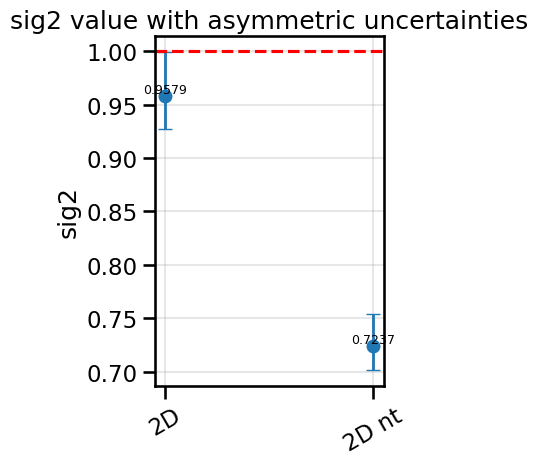

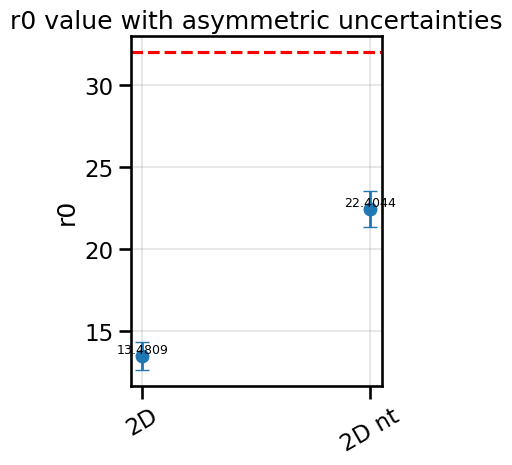

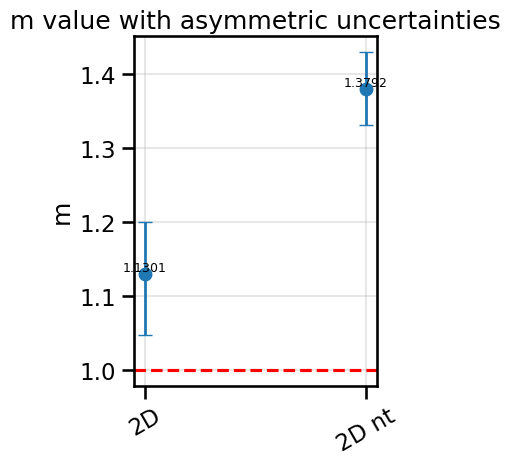

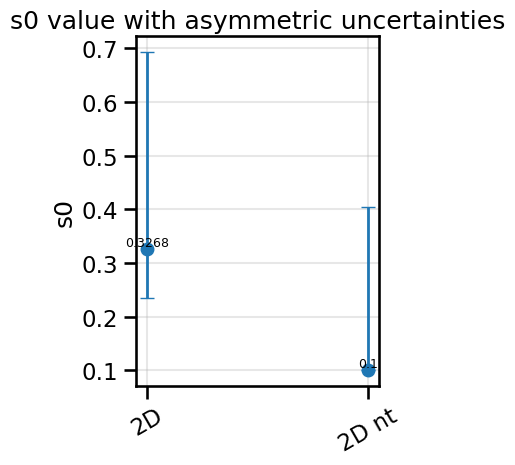

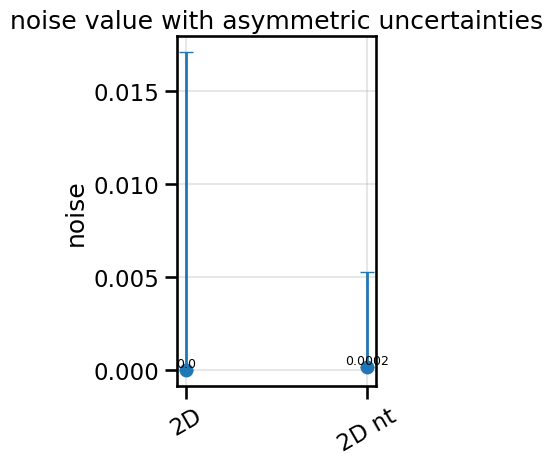

In [79]:
ci_results_compiler.plot_param(res,res0, labels=['2D','2D nt'], decimals=4, true = [1,32,1])


In [98]:
import bplot_ideal

In [112]:
import fit_structure_function
importlib.reload(fit_structure_function)  # reloads the updated code

<module 'fit_structure_function' from 'C:\\Users\\ZAINTEL2\\Dropbox\\GitHub\\fake_maps\\fit_structure_function.py'>

In [133]:
#results_ideal = fit_structure_function.fit_structure_function_ideal(sf, N, bfunc=bfunc,bplot_ideal=bplot_ideal, name = 'sf', data = 'sf')

In [87]:
# results0 = fit_structure_function.fit_structure_function_ideal(sf0, N, bfunc=bfunc, bplot=bplot, name = 'sf0', data = 'sf0')

In [ ]:
#results_ideal['result_emcee']

In [ ]:
#results['result_emcee']

# Dr. Will original jupyter file

## Compare pure power law with tapered power law

From PhD repository:
https://github.com/JavGVastro/PhD.Paper/blob/main/Fake-Maps/fake-maps-seeing.ipynb


The standard `make_extended()` function from `turbustat` gives a power law field (`vmap0`). 
I have modified it to use an exponential taper at large scales, which I use to make vmap (all other parameters are the same as `vmap0`).

In [8]:
r0 = 32.0
N = 256
m = 1.2
vmap = make_extended(
    N,
    powerlaw=2.0 + m,
    ellip=0.5,
    theta=45,
    correlation_length=r0,
    randomseed=2021_10_08,
)
signorm = vmap.std()
vmap /= signorm

vmap0 = make_extended(
    N,
    powerlaw=2.0 + m,
    ellip=0.5,
    theta=45,
    randomseed=2021_10_08,
)
signorm0 = vmap0.std()
vmap0 /= signorm0
signorm, signorm0

(4.399613458965609, 8.789997112996462)

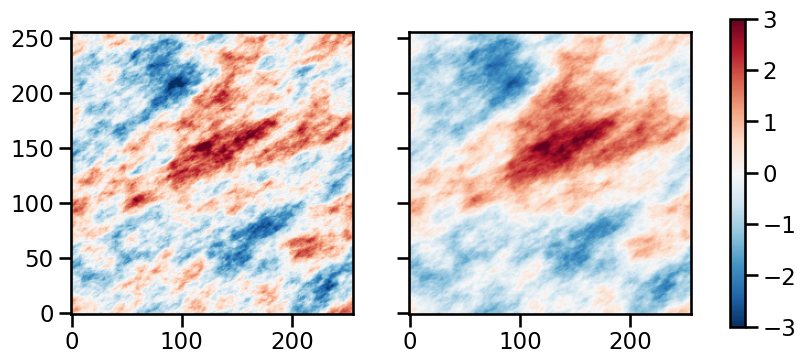

In [9]:


fig, (ax, axx) = plt.subplots(
    1,
    2,
    sharey=True,
    figsize=(10, 4),
)
imshow_kwds = dict(origin="lower", vmin=-3, vmax=3, cmap="RdBu_r")
im = ax.imshow(vmap, **imshow_kwds)
im = axx.imshow(vmap0, **imshow_kwds)
fig.colorbar(im, ax=[ax, axx])



In [10]:
fftmap = make_extended(
    N,
    powerlaw=2.0 + m,
    ellip=0.5,
    theta=45,
    correlation_length=r0,
    randomseed=2021_10_08,
    return_fft=True,
)
fftmap0 = make_extended(
    N,
    powerlaw=2.0 + m,
    ellip=0.5,
    theta=45,
    randomseed=2021_10_08,
    return_fft=True,
)

pmap = np.real(fftmap * np.conj(fftmap))
pmap0 = np.real(fftmap0 * np.conj(fftmap0))

C:\Users\ZAINTEL2\AppData\Local\Temp\ipykernel_19844\339815758.py:8: RuntimeWarning: divide by zero encountered in log10
  imm = axx.imshow(np.log10(pmap), **imshow_kwds)
C:\Users\ZAINTEL2\AppData\Local\Temp\ipykernel_19844\339815758.py:9: RuntimeWarning: invalid value encountered in divide
  im = ax.imshow((pmap / pmap0), cmap="gray_r", vmin=0.0, vmax=1.0)


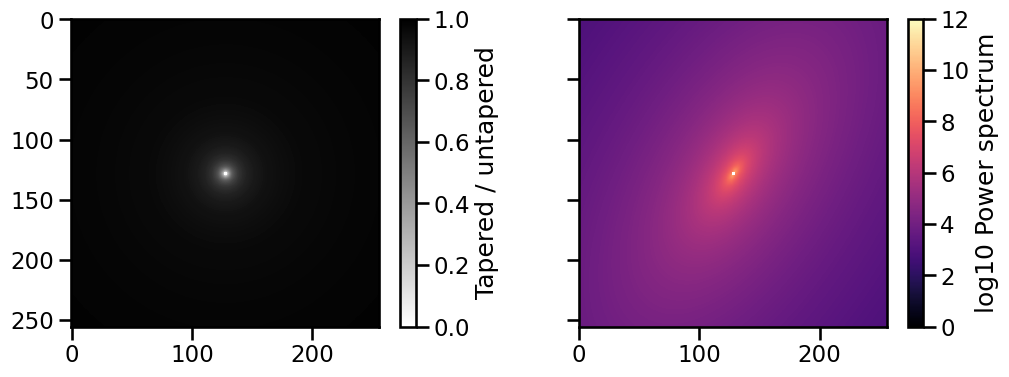

In [11]:
fig, (ax, axx) = plt.subplots(
    1,
    2,
    sharey=True,
    figsize=(12, 4),
)
imshow_kwds = dict(origin="lower", cmap="magma", vmin=0.0, vmax=12.0)
imm = axx.imshow(np.log10(pmap), **imshow_kwds)
im = ax.imshow((pmap / pmap0), cmap="gray_r", vmin=0.0, vmax=1.0)
fig.colorbar(im, ax=ax).set_label("Tapered / untapered")
fig.colorbar(imm, ax=axx).set_label("log10 Power spectrum")


The left-hand image is the ratio of the two power spectra on a linear inverted scale (white = 0, black = 1). It drops in the middle (low , large scales) as expected. The right-hand image is the power spectrum itself on a log scale

## Structure function of fake velocity map

In [12]:
sf = strucfunc.strucfunc_numba_parallel(vmap, dlogr=0.05)
sf0 = strucfunc.strucfunc_numba_parallel(vmap0, dlogr=0.05)

[None, None, (0.008, 4)]

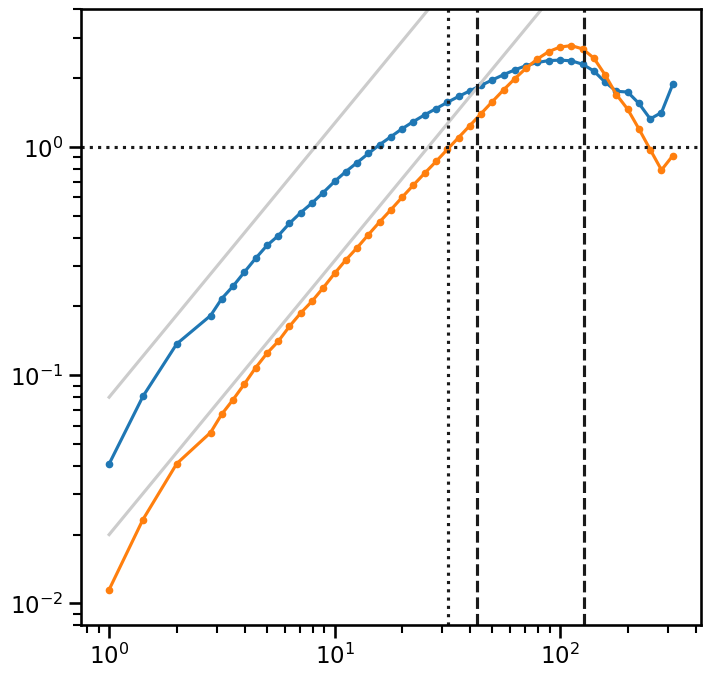

In [13]:
fig, ax = plt.subplots(
    figsize=(8, 8),
)
mask = sf["N pairs"] > 0
r = 10 ** sf["log10 r"][mask]
B = sf["Unweighted B(r)"][mask]
B0 = sf0["Unweighted B(r)"][mask]

ax.plot(r, B, marker=".")
ax.plot(r, B0, marker=".")

rgrid = np.logspace(0.0, 2.0)

for scale in 0.02, 0.08:
    ax.plot(rgrid, scale * rgrid ** m, color="0.8")

ax.axhline(1.0, color="k", linestyle="dotted")
ax.axvline(r0, color="k", linestyle="dotted")
ax.axvline(N / 2, color="k", linestyle="dashed")
ax.axvline(N / 6, color="k", linestyle="dashed")
ax.set(
    xscale="log",
    yscale="log",
    ylim=[8e-3, 4],
)

Note that:
- the untapered version (orange) has a good power law structure function that recovers m = 1.2 over a wide range of scales. But the tapered version (blue) flattens away from the power law quite quickly.
- Now that we are using a shallower power spectrum, we don't get the correlation length r0 to come out at exactly the tapering length that we fed in.
- The untapered structure function has a maximum at roughly half the box size and falls for larger scales. This is likely to be because of the periodic boundary conditions – we will investigate further below. Note that the derived r0 for the untapered version would be about 1/8 of the box size, but that this is not really a correlation length.

So we need a total field of view that is at least 8 times the correlation length in order to be able to recover the latter from the structure function


In [14]:
print("--- %s seconds ---" % (time.time()-start_time))

--- 587.3484585285187 seconds ---
